# NIH Chest X-ray (Sample) — Exploratory Data Analysis (EDA)

**Dataset:** `nih-chest-xrays/sample` (5,606 images + `sample_labels.csv`)

**Local run:** put the path to your unzipped data folder into `DATA_DIR` in Section 0.


## 0. Imports & locate the data

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Only edit this line: path to your unzipped data folder
DATA_DIR = "nih_sample" 

# Recursively find the csv and the images under DATA_DIR (no need to type subfolders)
csv_hits = glob.glob(os.path.join(DATA_DIR, "**", "sample_labels.csv"), recursive=True)
if not csv_hits:
    csv_hits = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)
assert csv_hits, f"No csv found under {DATA_DIR} — check the path"
csv_path = csv_hits[0]
print("CSV path:", csv_path)

# filename -> full path map, used later to display images
all_pngs = glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True)
img_map = {os.path.basename(p): p for p in all_pngs}
print("Images found:", len(all_pngs))

CSV path: /Users/dongtianxin/Desktop/20D_AI4ALL/nih_sample/sample_labels.csv
Images found: 11212


## 1. Load the data & basic structure

In [38]:
df = pd.read_csv(csv_path)

# The original csv often carries an empty 'Unnamed: 11' column — drop it
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Patient Age may be stored as text (e.g. "058Y") — extract digits and make it numeric
df["Patient Age"] = pd.to_numeric(
    df["Patient Age"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")

print("Shape (rows=images, cols=fields):", df.shape)
print("\nColumns:")
print(list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape (rows=images, cols=fields): (5606, 11)

Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']

First 3 rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,60,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,57,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,77,M,AP,2500,2048,0.168,0.168


In [39]:
print("Dtypes:")
print(df.dtypes)
print("\nUnique images (Image Index):", df["Image Index"].nunique())
print("Unique patients (Patient ID):", df["Patient ID"].nunique())

Dtypes:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImageWidth               int64
OriginalImageHeight              int64
OriginalImagePixelSpacing_x    float64
OriginalImagePixelSpacing_y    float64
dtype: object

Unique images (Image Index): 5606
Unique patients (Patient ID): 4230


## 2. Missing values

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values (label fields are complete)")
else:
    print("Missing values:")
    print(missing)

No missing values ✅ (label fields are complete)


## 3. Label distribution (multi-label)

Count per label (incl. No Finding):
Finding Labels
No Finding            3044
Infiltration           967
Effusion               644
Atelectasis            508
Nodule                 313
Mass                   284
Pneumothorax           271
Consolidation          226
Pleural_Thickening     176
Cardiomegaly           141
Emphysema              127
Edema                  118
Fibrosis                84
Pneumonia               62
Hernia                  13
Name: count, dtype: int64


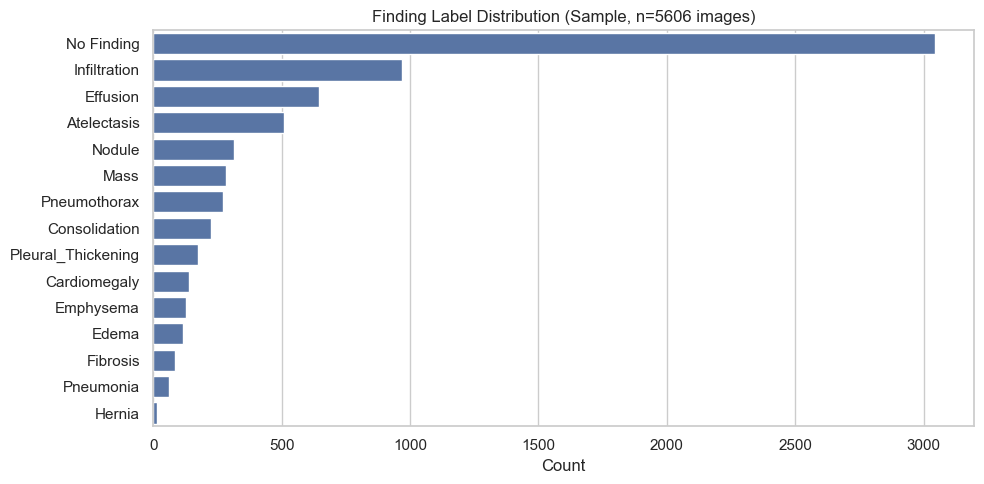

In [41]:
# One image can have several findings (separated by |), e.g. "Effusion|Infiltration"
# Split them and count how often each class appears
label_lists = df["Finding Labels"].str.split("|")
all_labels = label_lists.explode()
label_counts = all_labels.value_counts()

print("Count per label (incl. No Finding):")
print(label_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=label_counts.values, y=label_counts.index, color="#4C72B0")
plt.title("Finding Label Distribution (Sample, n=%d images)" % len(df))
plt.xlabel("Count"); plt.ylabel("")
plt.tight_layout(); plt.show()

In [42]:
# Binary view: healthy (No Finding) vs diseased (any finding) — key class imbalance
df["has_disease"] = (df["Finding Labels"] != "No Finding").astype(int)
binary = df["has_disease"].value_counts()
n_normal = int(binary.get(0,0)); n_disease = int(binary.get(1,0))

print(f"No Finding (healthy): {n_normal} ({n_normal/len(df)*100:.1f}%)")
print(f"Has disease         : {n_disease} ({n_disease/len(df)*100:.1f}%)")
print(f"Imbalance ratio  ~ 1 : {n_disease/max(n_normal,1):.2f}")

No Finding (healthy): 3044 (54.3%)
Has disease         : 2562 (45.7%)
Imbalance ratio  ~ 1 : 0.84


## 4. Demographics — the basis for the fairness audit

Age stats (raw):
count    5606.000000
mean       46.770068
std        17.407436
min         1.000000
25%        35.000000
50%        49.000000
75%        59.000000
max       411.000000
Name: Patient Age, dtype: float64

Implausible ages (>100): 1 records  <- data-quality issue / a cleaning point


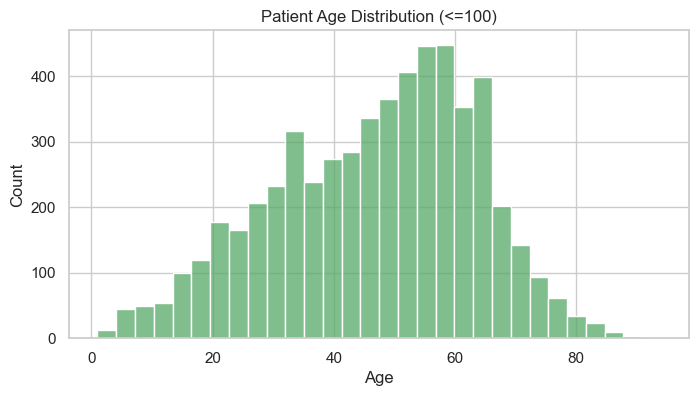

In [ ]:
# Patient Age
print("Age stats (raw):")
print(df["Patient Age"].describe())
bad_age = (df["Patient Age"] > 100).sum()
print(f"\nImplausible ages (>100): {bad_age} records")

# Filter out absurd values for plotting
age_clean = df.loc[df["Patient Age"] <= 100, "Patient Age"]
plt.figure(figsize=(8,4))
sns.histplot(age_clean, bins=30, color="#55A868")
plt.title("Patient Age Distribution (<=100)"); plt.xlabel("Age"); plt.show()

Gender distribution:
Patient Gender
M    3134
F    2472
Name: count, dtype: int64 

Patient Gender
M    55.9 %
F    44.1 %
Name: count, dtype: object

View position:
View Position
PA    3393
AP    2213
Name: count, dtype: int64


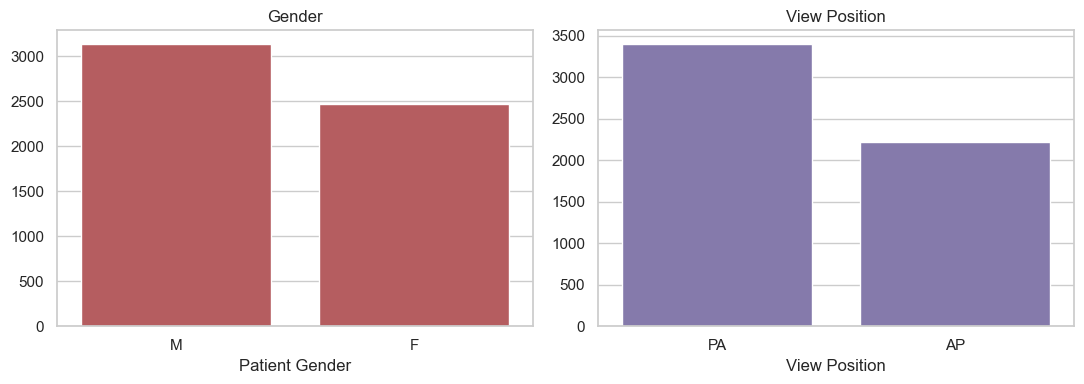

In [44]:
# --- Patient Gender ---
gender = df["Patient Gender"].value_counts()
print("Gender distribution:")
print(gender, "\n")
print((gender/len(df)*100).round(1).astype(str) + " %")

# --- View Position (AP vs PA) ---
view = df["View Position"].value_counts()
print("\nView position:")
print(view)

fig, ax = plt.subplots(1,2, figsize=(11,4))
sns.barplot(x=gender.index, y=gender.values, ax=ax[0], color="#C44E52"); ax[0].set_title("Gender")
sns.barplot(x=view.index, y=view.values, ax=ax[1], color="#8172B3"); ax[1].set_title("View Position")
plt.tight_layout(); plt.show()

## 5. Intersectional view: disease × demographics

Disease rate by gender:
Patient Gender
F    0.457
M    0.457
Name: has_disease, dtype: float64

Disease rate by age group:
age_group
0-30      0.417
31-50     0.420
51-70     0.495
71-100    0.538
Name: has_disease, dtype: float64


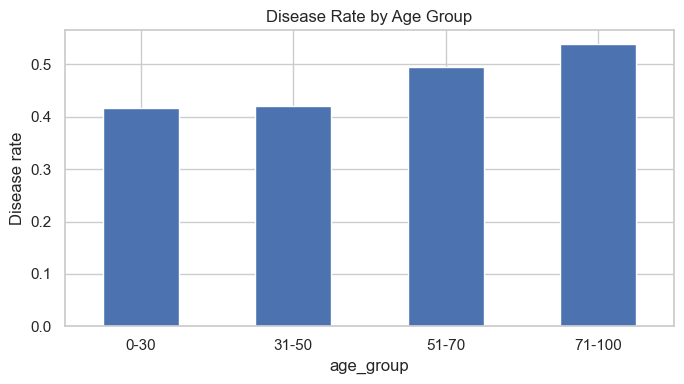

In [45]:
# Does disease rate differ by gender?
by_gender = df.groupby("Patient Gender")["has_disease"].mean().round(3)
print("Disease rate by gender:")
print(by_gender)

# By age group
df["age_group"] = pd.cut(df.loc[df["Patient Age"]<=100,"Patient Age"],
                         bins=[0,30,50,70,100],
                         labels=["0-30","31-50","51-70","71-100"])
by_age = df.groupby("age_group", observed=True)["has_disease"].mean().round(3)
print("\nDisease rate by age group:")
print(by_age)

plt.figure(figsize=(7,4))
by_age.plot(kind="bar", color="#4C72B0")
plt.title("Disease Rate by Age Group"); plt.ylabel("Disease rate"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 6. Patient-level check — prevent data leakage

In [46]:
imgs_per_patient = df.groupby("Patient ID").size()
print("Images per patient:")
print(imgs_per_patient.describe())
print("\nMost images for one patient:", imgs_per_patient.max())
print("Patients with more than 1 image:", (imgs_per_patient > 1).sum())

Images per patient:
count    4230.000000
mean        1.325296
std         0.852076
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
dtype: float64

Most images for one patient: 11
Patients with more than 1 image: 830


## 7. Sample images

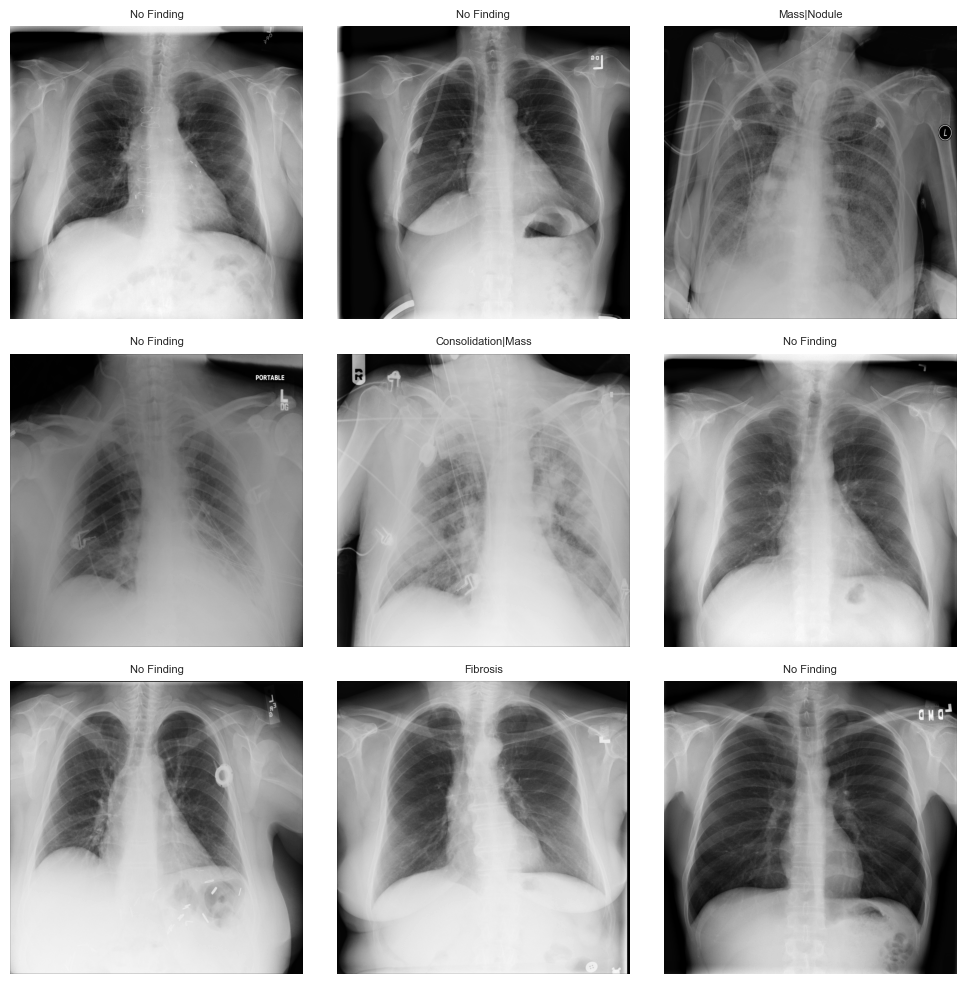

In [47]:
sample_rows = df.sample(9, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(3,3, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    fname = sample_rows.loc[i, "Image Index"]
    label = sample_rows.loc[i, "Finding Labels"]
    path = img_map.get(fname)
    if path:
        img = plt.imread(path)
        ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()